# Project: Expectation Decider


## Importing Libraries And Retriving Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2


df = pd.read_csv("expectation_decider_dataset.csv")

df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,12.0,84.4,Yes,46.1,Pass
1,9.4,87.4,Yes,61.0,Pass
2,12.6,95.2,Yes,70.1,Pass
3,16.1,94.8,Yes,70.7,Pass
4,9.1,58.3,Yes,63.2,Pass


## Section 1 Understanding the Basics

**What is Probability?**
Probability is a number between 0 and 1 that tells us how likely an event is to happen.
0 = impossible, 1 = certain. Formula: `P(Event) = favourable outcomes / total outcomes`.

**Key Terminology**
- **Experiment** – an action with an uncertain result (e.g. picking a student).
- **Sample Space** – all possible outcomes (all 200 students).
- **Event** – the outcome(s) we care about (e.g. "student passes").
- **Random Variable** – a number that comes out of a random event (e.g. number of passers).
- **Mutually Exclusive** – events that cannot happen together.
- **Independent Events** – one event does not affect the other's probability.
- **Conditional Probability** – probability of an event *given* another event already happened.

**Three example events from our dataset:**
1. A student studies more than 10 hours/week.
2. A student passes the final exam.
3. A student takes part in group discussion **and** passes the exam.

## Section 2 Empirical vs Theoretical Probability

- **Empirical probability** = based on real observed data (what actually happened).
- **Theoretical probability** = based on an assumption/logic, calculated without needing the real data.

In [3]:
total_pass = (df["final_exam_pass"] == "Pass").sum()
total_students = len(df)

p_pass_empirical = total_pass / total_students

print(f"Empiricial Probablity: {p_pass_empirical}")

Empiricial Probablity: 0.7


### Theoretical Probability

Theoretical probability is the likelihood of an event occurring based on the total number of possible outcomes. In this dataset, we use the records stored in `df` to calculate the probability of selecting a student who passed or failed. It is calculated as:

**Probability = (Number of Favorable Outcomes) / (Total Number of Outcomes)**

## Section 3: Random Variable & Probability Distribution

In [4]:
df_prob = pd.DataFrame({
    "X (passes out of 3)": [0, 1, 2, 3],
    "P(X)": [0.027, 0.189, 0.441, 0.343]
})

# Calculate X * P(X)
df_prob["X * P(X)"] = (
    df_prob["X (passes out of 3)"] * df_prob["P(X)"]
).round(3)

# Expected Value E[X]
expected_value = df_prob["X * P(X)"].sum().round(3)

# X - E[X]
df_prob["X - E[X]"] = (
    df_prob["X (passes out of 3)"] - expected_value
).round(3)

# (X - E[X])²
df_prob["(X - E[X])**2"] = (
    df_prob["X - E[X]"] ** 2
).round(3)

# (X - E[X])² × P(X)
df_prob["(X-E[X]**2) . P(Xi)"] = (
    df_prob["(X - E[X])**2"] * df_prob["P(X)"]
).round(3)

# Variance
variance = df_prob["(X-E[X]**2) . P(Xi)"].sum().round(3)

print("Expected Value (E[X]) =", expected_value)
print("Variance =", variance)

df_prob

Expected Value (E[X]) = 2.1
Variance = 0.63


,X (passes out of 3),P(X),X * P(X),X - E[X],(X - E[X])**2,(X-E[X]**2) . P(Xi)
0,0,0.027,0.000,-2.1,4.41,0.119
1,1,0.189,0.189,-1.1,1.21,0.229
2,2,0.441,0.882,-0.1,0.01,0.004
3,3,0.343,1.029,0.9,0.81,0.278


##  Section 4 Venn Diagram

- **Set A** = students who study more than 10 hours/week
- **Set B** = students who attend more than 80% of classes
- **A ∩ B** = students who satisfy both conditions

In [5]:
# find how many students belong to each set
set_A = df[df["study_hours"] > 10]
set_B = df[df["attendance"] > 80]
set_A_and_B = df[(df["study_hours"] > 10) & (df["attendance"] > 80)]

count_A = len(set_A)
count_B = len(set_B)
count_A_and_B = len(set_A_and_B)

print("Students in A (study > 10 hrs):", count_A)
print("Students in B (attendance > 80%):", count_B)
print("Students in A and B (both):", count_A_and_B)


Students in A (study > 10 hrs): 99
Students in B (attendance > 80%): 89
Students in A and B (both): 44


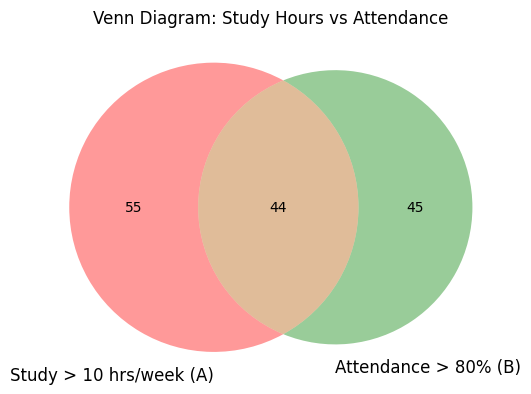

In [6]:
# draw the venn diagram using the counts above
only_A = count_A - count_A_and_B
only_B = count_B - count_A_and_B

plt.figure(figsize=(6, 5))
venn2(subsets=(only_A, only_B, count_A_and_B),
      set_labels=("Study > 10 hrs/week (A)", "Attendance > 80% (B)"))
plt.title("Venn Diagram: Study Hours vs Attendance")
plt.show()


## Section 5: Contingency Table & Probability Calculations

In [ ]:
contingency_table = pd.crosstab(df["group_discussion"], df["final_exam_pass"], margins=True,
                                 margins_name="Total")
contingency_table

final_exam_pass,Fail,Pass,Total
group_discussion,,,
No,30,50,80
Yes,30,90,120
Total,60,140,200


In [8]:
# read the exact numbers we need from the table
yes_and_pass = contingency_table.loc["Yes", "Pass"]
yes_total = contingency_table.loc["Yes", "Total"]
pass_total = contingency_table.loc["Total", "Pass"]
grand_total = contingency_table.loc["Total", "Total"]

# Joint Probability: P(Yes AND Pass)
joint_probability = yes_and_pass / grand_total
print("Joint Probability P(Group Discussion=Yes AND Pass) =", round(joint_probability, 3))

# Marginal Probability: P(Pass)
marginal_probability = pass_total / grand_total
print("Marginal Probability P(Pass) =", round(marginal_probability, 3))

# Conditional Probability: P(Pass | Yes)
conditional_probability = yes_and_pass / yes_total
print("Conditional Probability P(Pass | Group Discussion=Yes) =", round(conditional_probability, 3))

Joint Probability P(Group Discussion=Yes AND Pass) = 0.45
Marginal Probability P(Pass) = 0.7
Conditional Probability P(Pass | Group Discussion=Yes) = 0.75


## Section 7: Bayes' Theorem Application

In [ ]:
# 1. Store given facts as variables (translate word→symbol trick — your weak spot!)
P_HighAtt_given_Pass = 0.70   # keyword "of passers had" = conditional prob
P_HighAtt_given_Fail = 0.40   # same pattern, other group
P_HighAtt = 0.60               # keyword "of all students" = total/marginal prob

# 2. Spot the missing piece: P(Pass) not stated directly.
#    Whenever Bayes needs P(A) but only conditionals given → 
#    check if Law of Total Probability can back it out.

a = P_HighAtt_given_Pass
b = P_HighAtt_given_Fail
P_Pass = (P_HighAtt - b) / (a - b)   # algebra rearrange of total-prob equation
P_Fail = 1 - P_Pass

# 3. Now plug into Bayes formula:
#    P(A|B) = P(B|A) * P(A) / P(B)
P_Pass_given_HighAtt = (P_HighAtt_given_Pass * P_Pass) / P_HighAtt


0.7777777777777777